
载入程辑包：‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Attaching SeuratObject

载入需要的程辑包：BiocGenerics


载入程辑包：'BiocGenerics'


The following objects are masked from 'package:dplyr':

    combine, intersect, setdiff, union


The following objects are masked from 'package:stats':

    IQR, mad, sd, var, xtabs


The following objects are masked from 'package:base':

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min


载入需要的程辑包：GenomicRanges

载入需要的程辑包：stats4

载入需要的程辑包：S4Vectors


载入程辑包：'S4Vectors'


The following objec

AnnotationHub with 1 record
# snapshotDate(): 2022-10-31
# names(): AH75011
# $dataprovider: Ensembl
# $species: Homo sapiens
# $rdataclass: EnsDb
# $rdatadateadded: 2019-05-02
# $title: Ensembl 98 EnsDb for Homo sapiens
# $description: Gene and protein annotations for Homo sapiens based on Ensem...
# $taxonomyid: 9606
# $genome: GRCh38
# $sourcetype: ensembl
# $sourceurl: http://www.ensembl.org
# $sourcesize: NA
# $tags: c("98", "AHEnsDbs", "Annotation", "EnsDb", "Ensembl", "Gene",
#   "Protein", "Transcript") 
# retrieve record with 'object[["AH75011"]]' 

loading from cache

Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress 

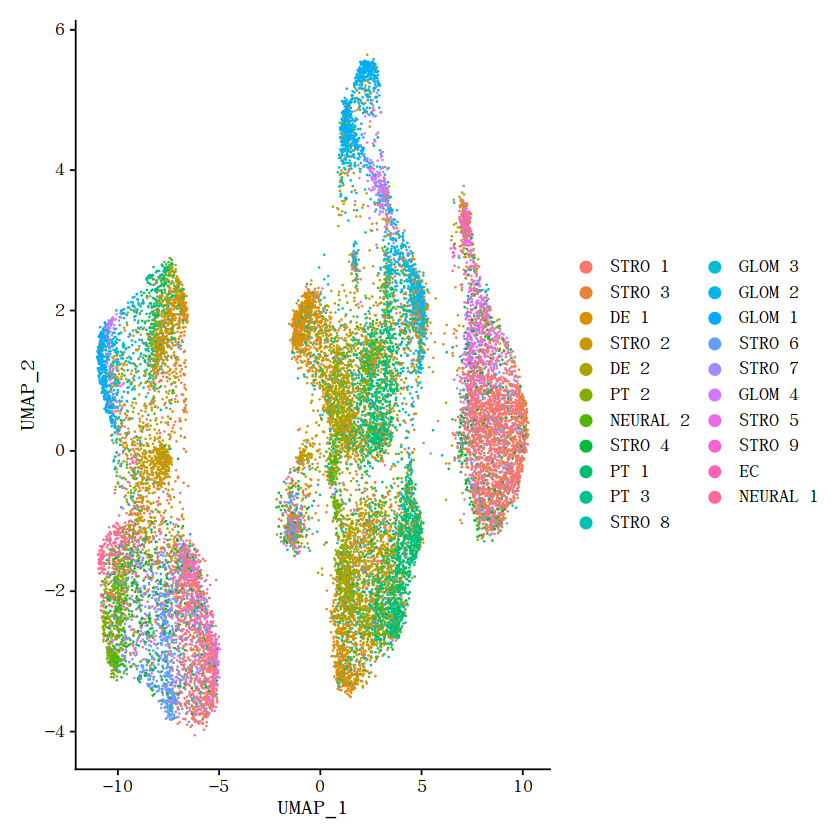

In [1]:
library(dplyr)
library(future)
library(Seurat)
library(Signac)
library(biovizBase)
library(ensembldb)
library(AnnotationHub)
library(GenomicRanges)


Epi17_peaks <- read.table(file = "/home/jsl/YBR/Ex4/Epi-17/Peaks.bed", col.names = c("chr", "start", "end"))
Cor15_peaks <- read.table(file = "/home/jsl/YBR/Ex4/Cor-15/Peaks.bed", col.names = c("chr", "start", "end"))
Epi17KO_peaks <- read.table(file = "/home/jsl/YBR/Ex4/Epi-17-KO/Peaks.bed", col.names = c("chr", "start", "end"))
Epi17_peaks <- makeGRangesFromDataFrame(Epi17_peaks)
Cor15_peaks <- makeGRangesFromDataFrame(Cor15_peaks)
Epi17KO_peaks <- makeGRangesFromDataFrame(Epi17KO_peaks)
combined.peaks <- reduce(x = c(Epi17_peaks, Cor15_peaks, Epi17KO_peaks))
peakwidths <- width(combined.peaks)
combined.peaks <- combined.peaks[peakwidths  < 10000 & peakwidths > 20]


Epi17_cell <- read.table("/home/jsl/YBR/Ex4/Epi-17/Cell_names.tsv", header = FALSE, sep = "\t", stringsAsFactors = FALSE)
Epi17_frag <-CreateFragmentObject(path = "/home/jsl/YBR/Ex4/Epi-17/fragments.tsv.gz", cells = Epi17_cell$V1)
Cor15_cell <- read.table("/home/jsl/YBR/Ex4/Cor-15/Cell_names.tsv", header = FALSE, sep = "\t", stringsAsFactors = FALSE)
Cor15_frag <-CreateFragmentObject(path = "/home/jsl/YBR/Ex4/Cor-15/fragments.tsv.gz", cells = Cor15_cell$V1)
Epi17KO_cell <- read.table("/home/jsl/YBR/Ex4/Epi-17-KO/Cell_names.tsv", header = FALSE, sep = "\t", stringsAsFactors = FALSE)
Epi17KO_frag <-CreateFragmentObject(path = "/home/jsl/YBR/Ex4/Epi-17-KO/fragments.tsv.gz", cells = Epi17KO_cell$V1)


makecore <- function(workcore, memory){
    plan("multisession", workers = workcore)
    options(future.globals.maxSize= memory * 1024 * 1024 ** 2)
    }
makecore(10, 10)
Epi17_ATAC_count <- FeatureMatrix(fragments = Epi17_frag, features = combined.peaks, cells = Epi17_cell$V1)
Cor15_ATAC_count <- FeatureMatrix(fragments = Cor15_frag, features = combined.peaks, cells = Cor15_cell$V1)
Epi17KO_ATAC_count <- FeatureMatrix(fragments = Epi17KO_frag, features = combined.peaks, cells = Epi17KO_cell$V1)


Epi17_ATAC_assay <- CreateChromatinAssay(Epi17_ATAC_count, fragments = Epi17_frag)
Epi17_Seurat <- CreateSeuratObject(Epi17_ATAC_assay, assay = "ATAC")
Cor15_ATAC_assay <- CreateChromatinAssay(Cor15_ATAC_count, fragments = Cor15_frag)
Cor15_Seurat <- CreateSeuratObject(Cor15_ATAC_assay, assay = "ATAC")
Epi17KO_ATAC_assay <- CreateChromatinAssay(Epi17KO_ATAC_count, fragments = Epi17KO_frag)
Epi17KO_Seurat <- CreateSeuratObject(Epi17KO_ATAC_assay, assay = "ATAC")
Epi17_Seurat$Sample <- "Epi17"
Cor15_Seurat$Sample <- "Cor15"
Epi17KO_Seurat$Sample <- "Epi17KO"
Combined <- merge(x = Epi17_Seurat, y = list(Cor15_Seurat, Epi17KO_Seurat), add.cell.ids = c("E17", "C15", "E17KO"))


RNA_count <- Matrix::readMM("/home/jsl/YBR/Ex4/Gene_Cell.mtx")
Gene_names <- read.table("/home/jsl/YBR/Ex4/Gene_names.tsv", header = FALSE, sep = ",")
Cell_names <- read.table("/home/jsl/YBR/Ex4/Cell_names.tsv", header = FALSE, sep = ",")
Cell_types <- read.table("/home/jsl/YBR/Ex4/Cell_types.tsv", header = FALSE, sep = ",")
Cell_names <- Cell_names %>% mutate(
    new_cell_id = case_when(
      grepl("-0$", V1) ~ paste0("E17_", gsub("-0$", "", V1)),
      grepl("-1$", V1) ~ paste0("C15_", gsub("-1$", "", V1)),
      grepl("-2$", V1) ~ paste0("E17KO_", gsub("-2$", "", V1)),
      TRUE ~ V1
    )
  )


RNA_count <- as(RNA_count, "dgCMatrix")
colnames(RNA_count) <- Cell_names$new_cell_id
rownames(RNA_count) <- Gene_names$V1
rownames(Cell_types) <- Cell_names$new_cell_id 
Combined <- Combined[, intersect(colnames(RNA_count), colnames(Combined))]
Combined[["RNA"]] <- CreateAssayObject(counts = RNA_count[, intersect(colnames(RNA_count), colnames(Combined))])
Combined$cell_types <- Cell_types$V1
std_chr <- GenomeInfoDb::standardChromosomes(granges(Combined))
peaks.keep <- as.character(seqnames(granges(Combined))) %in% as.vector(std_chr)
Combined <- Combined[as.vector(peaks.keep), ]
Combined <- Combined[, intersect(colnames(RNA_count), colnames(Combined))]
Combined[["RNA"]] <-CreateAssayObject(counts = RNA_count[, intersect(colnames(RNA_count), colnames(Combined))])


ah <- AnnotationHub(localHub = FALSE)
query(ah, "EnsDb.Hsapiens.v98")
ensdb_v98 <- ah[["AH75011"]]
annotations <-GetGRangesFromEnsDb(ensdb = ensdb_v98)
seqlevels(annotations) <-paste0("chr", seqlevels(annotations))
genome(annotations) <-"hg38"
Annotation(Combined) <- annotations


DefaultAssay(Combined) <- "ATAC"
Combined <- RunTFIDF(Combined)
Combined <- FindTopFeatures(Combined, min.cutoff = "q5")
Combined <-RunSVD(Combined)
Combined <-FindNeighbors(object = Combined, reduction = "lsi", dims = 2:50)
Combined <-FindClusters(object = Combined, verbose = FALSE, algorithm = 3)
Combined <-RunUMAP(Combined, dims = 2:50, reduction = "lsi")
Idents(Combined) <- Cell_types$V1
DimPlot(Combined, pt.size = 0.1)

In [5]:
makecore <- function(workcore, memory){
    plan("multisession", workers = workcore)
    options(future.globals.maxSize= memory * 1024 * 1024 ** 2)
    }
makecore(10, 20)
gene.activities <- GeneActivity(Combined)
Combined[["RNA"]] <- CreateAssayObject(counts = gene.activities)
Combined <- NormalizeData(object = Combined, assay = "RNA", normalization.method = "LogNormalize",
                                                scale.factor = median(Combined$nCount_RNA))
Matrix::writeMM(Combined[["RNA"]]@counts, file = "./ComicGTN/data/ARPKD_kidney/Gene_Cell_Activity.mtx")

Extracting gene coordinates

Extracting reads overlapping genomic regions

Extracting reads overlapping genomic regions

Extracting reads overlapping genomic regions



Assay data with 19615 features for 20809 cells
First 10 features:
 PLCXD1, GTPBP6, PPP2R3B, SHOX, CRLF2, CSF2RA, IL3RA, SLC25A6, ASMTL,
P2RY8 

In [2]:
library(ggplot2)
library(TFBSTools)
library(patchwork)
library(ggseqlogo)
library(JASPAR2020)
library(BSgenome.Hsapiens.UCSC.hg38)


pfm <- getMatrixSet(x = JASPAR2020, opts = list(collection = "CORE", tax_group = "vertebrates", all_versions = FALSE))
Combined <- AddMotifs(object = Combined, genome = BSgenome.Hsapiens.UCSC.hg38, pfm = pfm)
da_peaks <- FindMarkers(object = Combined, ident.1 = "GLOM 4",ident.2 = "GLOM 1", only.pos = TRUE,
                                          test.use = "LR", min.pct = 0.05, latent.vars = "nCount_ATAC")
top.da.peak <- rownames(da_peaks[da_peaks$p_val < 0.005 & da_peaks$pct.1 > 0.2, ])
enriched.motifs <-FindMotifs(object = Combined, features = top.da.peak)



载入需要的程辑包：BSgenome

载入需要的程辑包：Biostrings

载入需要的程辑包：XVector


载入程辑包：'Biostrings'


The following object is masked from 'package:base':

    strsplit


载入需要的程辑包：rtracklayer


载入程辑包：'rtracklayer'


The following object is masked from 'package:AnnotationHub':

    hubUrl


Building motif matrix

Warning message in .merge_two_Seqinfo_objects(x, y):
"Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrM, chr1_GL383518v1_alt, chr1_GL383519v1_alt, chr1_GL383520v2_alt, chr1_KI270759v1_alt, chr1_KI270760v1_alt, chr1_KI270761v1_alt, chr1_KI270762v1_alt, chr1_KI270763v1_alt, chr1_KI270764v1_alt, chr1_KI270765v1_alt, chr1_KI270766v1_alt, chr1_KI270892v1_alt, chr2_GL383521v1_alt, chr2_GL383522v1_alt, chr2_GL582966v2_alt, chr2_KI270767v1_alt, chr2_KI270768v1_alt, chr2_KI270769v1_alt, chr2_KI270770v1_alt, chr2_KI270771v1_alt, chr2_KI270772v1_alt, chr2_KI270773v1_alt, chr2_KI270774v1_alt, chr2_KI270775v1_alt, chr2_KI270776v1_alt, chr2_KI270893v1_alt, chr2_KI270894v1_alt,

Finding motif positions

Warning message in .merge_two_Seqinfo_objects(x, y):
"Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrM, chr1_GL383518v1_alt, chr1_GL383519v1_alt, chr1_GL383520v2_alt, chr1_KI270759v1_alt, chr1_KI270760v1_alt, chr1_KI270761v1_alt, chr1_KI270762v1_alt, chr1_KI270763v1_alt, chr1_KI270764v1_alt, chr1_KI270765v1_alt, chr1_KI270766v1_alt, chr1_KI270892v1_alt, chr2_GL383521v1_alt, chr2_GL383522v1_alt, chr2_GL582966v2_alt, chr2_KI270767v1_alt, chr2_KI270768v1_alt, chr2_KI270769v1_alt, chr2_KI270770v1_alt, chr2_KI270771v1_alt, chr2_KI270772v1_alt, chr2_KI270773v1_alt, chr2_KI270774v1_alt, chr2_KI270775v1_alt, chr2_KI270776v1_alt, chr2_KI270893v1_alt, chr2_KI270894v1_alt, chr3_GL383526v1_alt, chr3_JH636055v2_alt, chr3_KI270777v1_alt, chr3_KI270778v1_alt, chr3_KI270779v1_alt, chr3_KI270780v1_alt, chr3_KI270781v1_alt, chr3_KI270782v1_alt, chr3_KI270783v1_alt, chr3_KI270784v1_alt, chr3_KI270895v1_alt, chr3_KI270924v1_alt, chr3_KI270934v1

Creating Motif object

Warning message in RegionStats.default(object = regions, genome = genome, verbose = verbose, :
"Not all seqlevels present in supplied genome"
Selecting background regions to match input sequence characteristics

Matching GC.percent distribution

Testing motif enrichment in 2 regions

Warning message in FindMotifs(object = Combined, features = top.da.peak):
"Testing motif enrichment using a small number of regions is not recommended"


Computing GC bias per region

Warning message in .merge_two_Seqinfo_objects(x, y):
"Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrM, chr1_GL383518v1_alt, chr1_GL383519v1_alt, chr1_GL383520v2_alt, chr1_KI270759v1_alt, chr1_KI270760v1_alt, chr1_KI270761v1_alt, chr1_KI270762v1_alt, chr1_KI270763v1_alt, chr1_KI270764v1_alt, chr1_KI270765v1_alt, chr1_KI270766v1_alt, chr1_KI270892v1_alt, chr2_GL383521v1_alt, chr2_GL383522v1_alt, chr2_GL582966v2_alt, chr2_KI270767v1_alt, chr2_KI270768v1_alt, chr2_KI270769v1_alt, chr2_KI270770v1_alt, chr2_KI270771v1_alt, chr2_KI270772v1_alt, chr2_KI270773v1_alt, chr2_KI270774v1_alt, chr2_KI270775v1_alt, chr2_KI270776v1_alt, chr2_KI270893v1_alt, chr2_KI270894v1_alt, chr3_GL383526v1_alt, chr3_JH636055v2_alt, chr3_KI270777v1_alt, chr3_KI270778v1_alt, chr3_KI270779v1_alt, chr3_KI270780v1_alt, chr3_KI270781v1_alt, chr3_KI270782v1_alt, chr3_KI270783v1_alt, chr3_KI270784v1_alt, chr3_KI270895v1_alt, chr3_KI270924v1_alt, chr3_KI270

Selecting background regions

Computing deviations from background

Constructing chromVAR assay



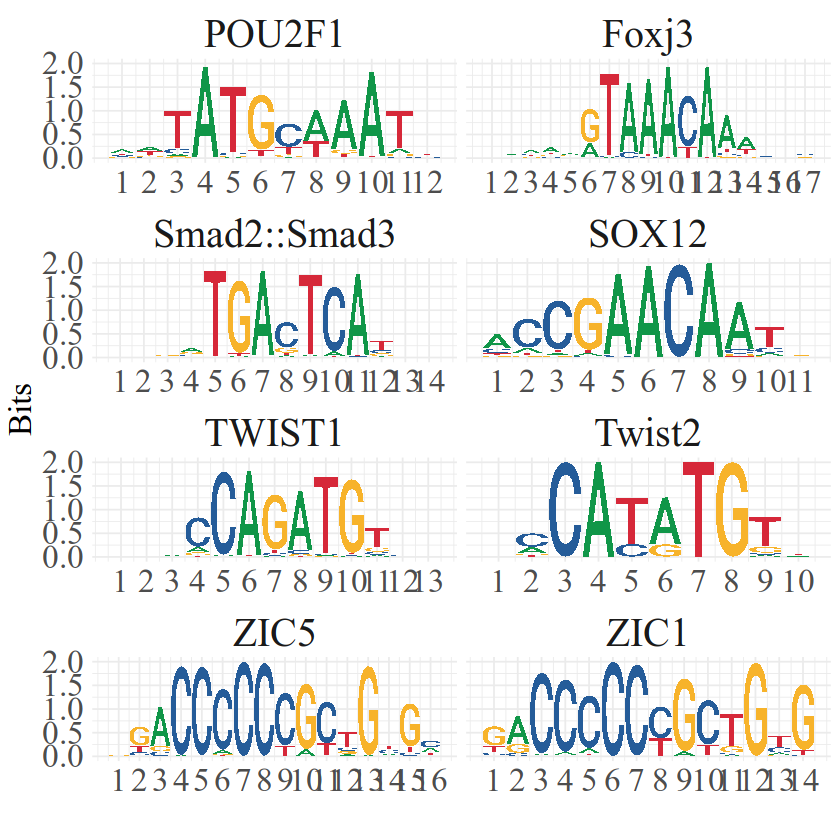

In [3]:
Combined <- RunChromVAR(object = Combined, genome = BSgenome.Hsapiens.UCSC.hg38)
DefaultAssay(Combined) <- "chromvar"
differential.activity <- FindMarkers(object = Combined, ident.1 = "GLOM 4", ident.2 = "GLOM 1", 
                                                         only.pos = TRUE, mean.fxn = rowMeans, fc.name = "avg_diff")
p <- MotifPlot(object = Combined, motifs = rownames(differential.activity)[1:8], assay = "ATAC")
p + theme_minimal()+theme(text = element_text(family = "Times New Roman", size = 30),
                                                axis.title = element_text(size = 20), axis.text = element_text(size = 20))
p + theme_minimal()+theme(text = element_text(family = "Times New Roman", size = 30),
                                                axis.title = element_text(size = 20), axis.text = element_text(size = 20))

Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message:
"Removed 146 rows containing missing values or values outside the scale range (`geom_segment()`)."
Warning message:
"Removed 15 rows containing missing values or values outside the scale range (`geom_segment()`)."


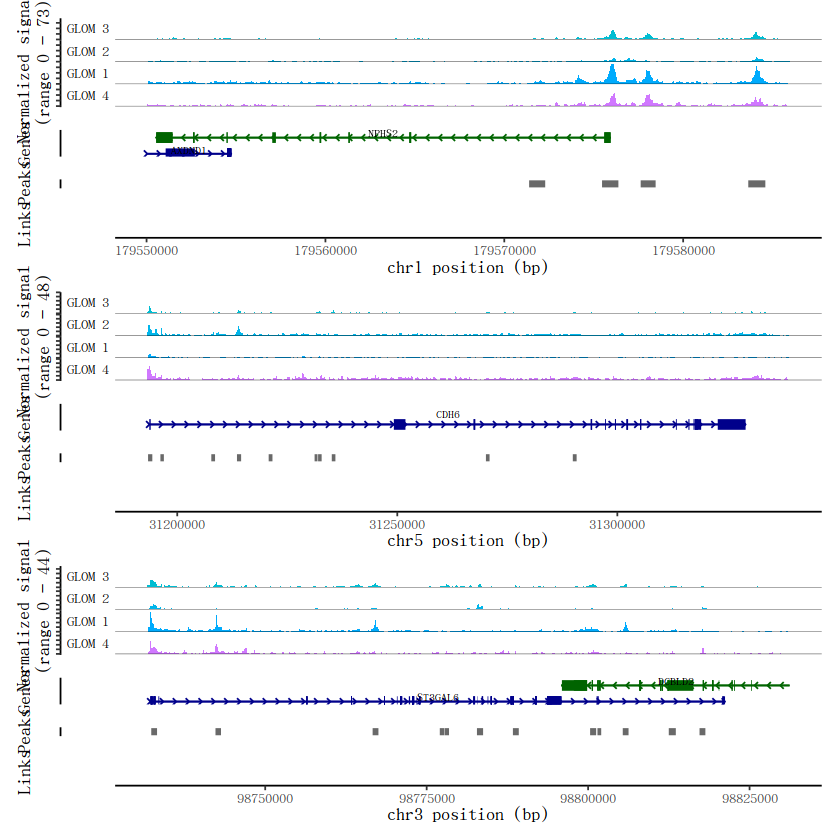

In [7]:
idents.plot <- c("GLOM 1", "GLOM 2", "GLOM 3", "GLOM 4")
DefaultAssay(Combined) <- "ATAC"
CoveragePlot(object = Combined, region = c("NPHS2", "CDH6", "ST3GAL6"),
                       idents = idents.plot, extend.upstream = 500, extend.downstream = 10000, ncol = 1)

In [2]:
library(SeuratWrappers)
library(ggplot2)
library(patchwork)
library(cicero)
library(Biobase)
data <- as(as.matrix(Combined@assays$ATAC@counts), "sparseMatrix")


pd <- new("AnnotatedDataFrame", data = Combined@meta.data)
fData <- data.frame(gene_short_name = row.names(data), row.names = row.names(data))
fd <- new("AnnotatedDataFrame", data = fData)
colnames(data) <- as.character(colnames(data))
rownames(pd) <- as.character(rownames(pd))
Combined.cds <- monocle::newCellDataSet(data, phenoData = pd, featureData = fd, expressionFamily = negbinomial.size())


Combined.cicero <- make_cicero_cds(Combined.cds, reduced_coordinates = as.data.frame(Combined@reductions$umap@cell.embeddings))
DefaultAssay(Combined) <- "ATAC"
genome <- seqlengths(Annotation(Combined))
genome1 <- genome[5]
genome1.df <- data.frame("chr" = names(genome1), "length" = genome1)


conns <- run_cicero(Combined.cicero, genome1.df, sample_num =100)
ccans <-generate_ccans(conns)
links <- ConnectionsToLinks(conns = conns, ccans = ccans)
Links(Combined) <- links
idents.plot <- c("GLOM 1", "GLOM 2", "GLOM 3", "GLOM 4")
p1 <- CoveragePlot(Combined, region = "ST3GAL6", idents = idents.plot, extend.upstream = 500, extend.downstream = 10000)

载入需要的程辑包：monocle

载入需要的程辑包：Matrix


载入程辑包：'Matrix'


The following object is masked from 'package:S4Vectors':

    expand


载入需要的程辑包：VGAM

载入需要的程辑包：splines

载入需要的程辑包：DDRTree

载入需要的程辑包：irlba

载入需要的程辑包：Gviz

载入需要的程辑包：grid


载入程辑包：'Gviz'


The following object is masked from 'package:AnnotationFilter':

    feature


Warning message in asMethod(object):
"sparse->dense coercion: allocating vector of size 17.5 GiB"
Overlap QC metrics:
Cells per bin: 50
Maximum shared cells bin-bin: 44
Mean shared cells bin-bin: 0.120114369604867
Median shared cells bin-bin: 0

Warning message in asMethod(object):
"sparse->dense coercion: allocating vector of size 3.3 GiB"


[1] "Starting Cicero"
[1] "Calculating distance_parameter value"
[1] "Running models"
[1] "Assembling connections"
[1] "Successful cicero models:  770"
[1] "Other models: "

Zero or one element in range 
                          24 
[1] "Models with errors:  0"
[1] "Done"
[1] "Coaccessibility cutoff used: 0.31"


Warning message:
"Removed 15 rows containing missing values or values outside the scale range (`geom_segment()`)."
